In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [21]:
# Load your dataset
df = pd.read_csv("updated_labels.csv")

# Separate features and label
X = df.drop("Label", axis=1)
y = df["Label"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


In [22]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification (Normal vs DDoS)
])


C:\Users\amrut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9946 - loss: 0.0272 - val_accuracy: 0.9984 - val_loss: 0.0068
Epoch 2/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9982 - loss: 0.0071 - val_accuracy: 0.9990 - val_loss: 0.0037
Epoch 3/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9993 - val_loss: 0.0023
Epoch 4/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 5/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9996 - val_loss: 0.0012
Epoch 6/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 7/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 8/30
2213/2213 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9995 - loss: 0

In [24]:
# Predict on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Print performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


2371/2371 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Accuracy: 0.9998681695339793

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     24192
         1.0       1.00      1.00      1.00     51663

    accuracy                           1.00     75855
   macro avg       1.00      1.00      1.00     75855
weighted avg       1.00      1.00      1.00     75855



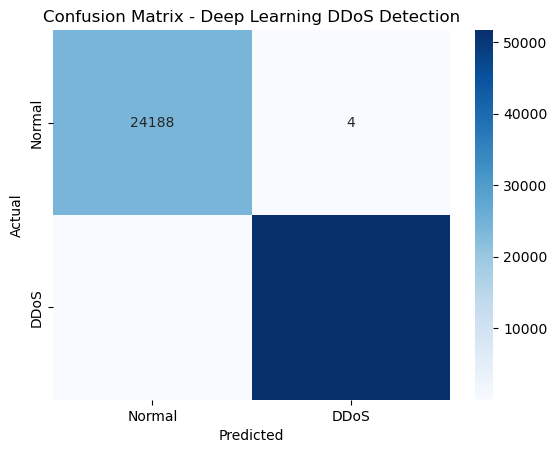

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'DDoS'], yticklabels=['Normal', 'DDoS'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Deep Learning DDoS Detection")
plt.show()


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities → class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


2371/2371 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9999
F1 Score : 0.9999


In [27]:
model.save("ddos_model.h5")
